# How do we estimate photon images? 

Basic image calibration is the same as for imaging. The number of photons recorded in a pixel $\sf N_{light}~[photons]$ can be written in terms of a light exposure $\sf E_{light}~[ADU]$ and calibrations as

$$\sf  N_{light} = g(E_{light} - \dot{E}_{dark}t_{light} - E_{bias})$$

or if the dark exposure is the same duration as the light exposure

$$\sf  N_{light} = g(E_{light} - E_{dark})$$

or if the dark current is negligible

$$\sf  N_{light} = g(E_{light} - E_{bias})$$

where $\sf g$ is the gain of the detector, in units of $\sf [photons/ADU]$.

## Photons in SBO Images 
Let's first estimate a photon image for the SBO spectrograph. We'll use an arclamp image, which we can also extract to get a spectrum we can use for wavelength calibration.

In [ ]:
# basic imports 
import matplotlib.pyplot as plt 
import numpy as np
import astropy.units as u 
import glob

# some fancier astropy imports
from astropy.io import fits 
from astropy.table import QTable
from astropy.stats import mad_std
from specutils import Spectrum 

# make interactive plots
%matplotlib ipympl

The CMOS detector used in the SBO spectrograph is pretty uniform, so we can we just use constants as pretty good estimates of the bias level $\sf E_{bias}$ and gain $\sf g$. Here we'll neglect dark current, but we probably wouldn't want to if we were taking a much longer exposure of some faint astronomical source.

In [36]:
# estimated the bias from a zero-second exposure
E_bias = 12*u.adu 

# estimated the gain from the noise in a sequence of flat-fields
g = 0.266*u.photon/u.adu

# estimated the read noise from a sequence of biases
sigma_RN_adu = 5.3*u.adu 
sigma_RN = g*sigma_RN_adu


With those basic cartoon calibrations defined, let's look at an image with the 24" spectrograph. 

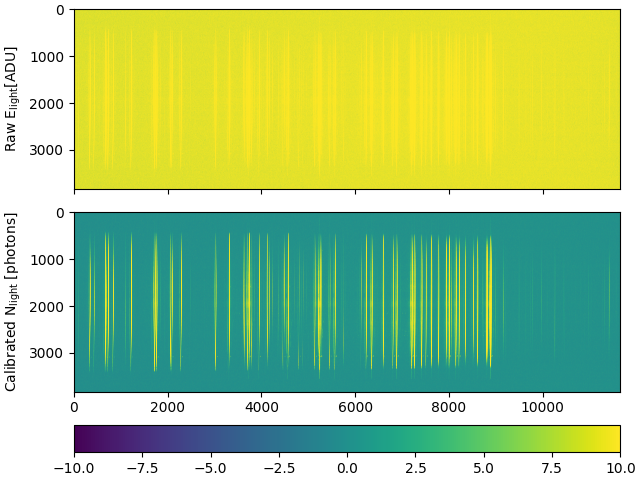

In [37]:
# load a raw fits image
f= 'data/Leto-Spectra-HeNeAr-10-20-06_32_19Z-00001.fits'
hdu = fits.open(f)

# convert from ADU to photons (neglecting dark current)
E = hdu[0].data*u.adu
t = hdu[0].header['EXPTIME']*u.s
N = g*(E - E_bias)

# imshow the data
fi, ax = plt.subplots(2, 1, sharex=True, sharey=True, constrained_layout=True)
plt.sca(ax[0])
imshow_kw = dict(vmin=-10, vmax=10)
plt.imshow(E.value, **imshow_kw)
plt.ylabel(r'Raw $\sf E_{light} [ADU]$')
plt.sca(ax[1])
plt.imshow(N.value, **imshow_kw)
plt.ylabel(r'Calibrated $\sf N_{light}$ [photons]')
plt.colorbar(orientation='horizontal');

Looking at the raw and calibrated images, we can see that subtracting the bias means that our calibrated image starts close to 0 for regions that aren't highly illuminated. That's what we want!

## Extracting a Simple 1D Spectrum

Below we're going to define a very simple horizontal boxcar and sum all the photons in it to be our spectrum. For real science data, you probably want to do something more clever using some [fancier tools](tools.ipynb), but for conceptual purposes here we'll keep it simple here. We'll extract 1D spectrum from the middle rows of the detector as the sum over a horizontal band across our 2D spectrum image. 

If $\sf N_{light}$ is the number of photons that hit a pixel, the uncertainty associated with each pixel is $$\sf \sigma_{N_{light}} = \sqrt{N_{light} + \sigma_{RN, photons}^2}$$

If we extract a spectrum as the sum over $\sf n$ rows in an aperture
$$\sf S = \sum_{n} N_{light}$$
then the uncertainty on the extracted 1D spectrum will by propagation of uncertainties be
$$\sf \sigma_S = \sqrt{\sum_{n} \sigma_{N_{light}}^2} = \sqrt{S + n\sigma_{RN, photons}^2}$$
which we could use to define an effective signal-to-noise ration S/N as 
$$\sf S/N = S/\sigma_S$$
This estimate for $\sf S/N$ works if all the photons in $\sf N_{light}$ are ones we care about. If $\sf N_{light} = N_{astronomical} + N_{sky}$, then we probably need to estimate 
$$\sf S_{astronomical} = S_{light} - S_{sky}$$
and
$$\sf \sigma_{S_{astronomical}} = \sqrt{S_{astronomical} + S_{sky} + n\sigma_{RN, photons}^2}$$

where $S_{sky}$ is an estimate of the sky brightness probably estimated from a region immediately above or below the astronomical source. 

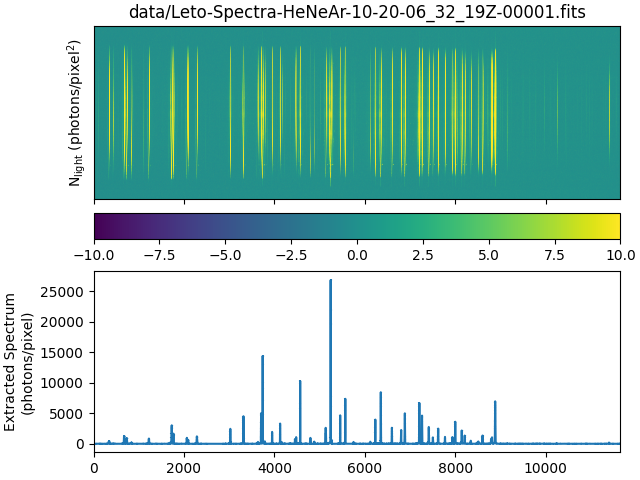

In [38]:
# define an extraction width 
width=10

# find the middle row of the detector
middle = int(E.shape[0]/2)

# calculate the sum in the aperture
S = np.sum(N[middle-int(width/2):middle+int(width/2), :], 0)

# calculate the uncertainty per extracted pixel
sigma_S = np.sqrt(width*sigma_RN.value**2 + S.value)*u.photon

spectrum = QTable(dict(wavelength_pixel=np.arange(E.shape[1])*u.pixel, 
                       flux=S/t/u.pixel,
                    uncertainty=sigma_S/t/u.pixel))

fi, ax = plt.subplots(2, 1, sharex=True, constrained_layout=True)
plt.sca(ax[0])
plt.imshow(N.value, **imshow_kw)
plt.title(f)
plt.ylabel(r'$\sf N_{light}$ (photons/pixel$^2$)')
plt.yticks([])
plt.colorbar(orientation='horizontal')
plt.sca(ax[1])
w = np.arange(len(S))
plt.errorbar(spectrum['wavelength_pixel'], 
             spectrum['flux'], 
             spectrum['uncertainty'])
plt.ylabel('Extracted Spectrum\n(photons/pixel)');

Now, let's add a little metadata to this `astropy` table we've created, and save it to a file.

In [34]:
t = spectrum
t.meta['telescope'] = 'Sommers-Bausch Observatory Leto (24")'
t.meta['grating-tilt'] = 'about -10 degrees'
t.meta['slit-width'] = '20 microns'
t.meta['focus'] = 'probably not great'
t.meta['lamp(s)'] = 'HeNeAr'
t.write('sbo-example-HeNeAr.ecsv', overwrite=True)

In [35]:
t

wavelength_pixel,flux,uncertainty
pix,ph / (pix s),ph / (pix s)
float64,float64,float64
0.0,13.566,5.782850542768679
1.0,5.32,5.019498022711036
2.0,3.99,4.885218562152567
3.0,6.118,5.098368405676467
4.0,7.448,5.22717518359582
5.0,23.40800000000001,6.579009074321148
6.0,-1.596,4.275436866566971
7.0,10.374,5.499941854238098


From here, we can start playing with fitting line profiles, finding lots of lines, and wavelength calibration!